---
# LH Nautical — Relatório Final de Dados
### Desafio Técnico — Indicium

**Período analisado:** Janeiro/2023 – Dezembro/2024  
**Bases utilizadas:** Vendas, Produtos, Clientes, Custos de Importação, Câmbio BCB/PTAX  
**Metodologia:** EDA → Tratamento → Análise → Previsão → Recomendação  
**Achado central:** margem real de **-5,3%** (R$-139M) revelada pela integração com a API do Banco Central

---

### Como Executar Este Notebook
1. Execute as células em ordem, do topo ao fim.
2. Este notebook lê as tabelas Silver (`silver_produtos`, `silver_clientes`) e Gold (`gold_fct_vendas`) do Delta Lake.
3. Os números exibidos devem refletir o período Jan/2023 a Dez/2024.
4. Ao final, rode a célula de checks para validar consistência geral da apresentação final.

In [0]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Compatibilidade: Databricks Runtime (UI) vs databricks-connect (VS Code) ─
try:
    spark  # já definido no Databricks runtime
    dbutils.widgets.text("catalog", "workspace",   "Catalog")
    dbutils.widgets.text("schema",  "lh_nautical", "Schema")
    CATALOG = dbutils.widgets.get("catalog")
    SCHEMA  = dbutils.widgets.get("schema")
except NameError:
    from databricks.connect import DatabricksSession
    spark   = DatabricksSession.builder.serverless().getOrCreate()
    CATALOG = "workspace"
    SCHEMA  = "lh_nautical"

vendas_gold = spark.table(f"{CATALOG}.{SCHEMA}.gold_fct_vendas").toPandas()
vendas_gold["sale_date"] = pd.to_datetime(vendas_gold["sale_date"])

produtos = spark.table(f"{CATALOG}.{SCHEMA}.silver_produtos").toPandas()
clientes = spark.table(f"{CATALOG}.{SCHEMA}.silver_clientes").toPandas()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"

print(f"vendas_gold: {len(vendas_gold):,} | produtos: {len(produtos)} | clientes: {len(clientes)}")
print("Setup concluido.")
# ── Paleta de cores do projeto ─────────────────────────────────────────────
COR_PRIMARIA  = '#2E86AB'
COR_DESTAQUE  = '#E74C3C'
COR_POSITIVO  = '#27AE60'
COR_RISCO     = '#F39C12'
COR_NEUTRO    = '#95A5A6'


vendas_gold: 9,895 | produtos: 150 | clientes: 49
Setup concluido.


In [0]:
# ── Catálogo Delta Lake disponível ──────────────────────────────────────────
spark.sql("SHOW TABLES IN workspace.lh_nautical").show(truncate=False)

+-----------+--------------------+-----------+
|database   |tableName           |isTemporary|
+-----------+--------------------+-----------+
|lh_nautical|bronze_clientes     |false      |
|lh_nautical|bronze_custos       |false      |
|lh_nautical|bronze_produtos     |false      |
|lh_nautical|bronze_vendas       |false      |
|lh_nautical|gold_fct_vendas     |false      |
|lh_nautical|silver_cambio       |false      |
|lh_nautical|silver_clientes     |false      |
|lh_nautical|silver_custos       |false      |
|lh_nautical|silver_produtos     |false      |
|lh_nautical|silver_vendas       |false      |
|lh_nautical|vwp_kpis_cliente    |false      |
|lh_nautical|vwp_kpis_mensal     |false      |
|lh_nautical|vwp_kpis_produto    |false      |
|lh_nautical|vwp_resumo_executivo|false      |
+-----------+--------------------+-----------+



%pip install scikit-learn statsmodels -q

---
## 1. O Problema

A LH Nautical chegou ao projeto com quatro bases de dados desorganizadas:
- **Vendas** com datas em formatos mistos
- **Produtos** com preços como texto e 39 variações de categoria para apenas 3 reais
- **Clientes** com 30 emails corrompidos e endereços sem padrão
- **Custos** com histórico aninhado em listas dentro de JSON

Durante a análise, uma **quinta fonte** foi integrada: o **câmbio histórico (BCB/PTAX)** via API pública do Banco Central do Brasil — 731 dias de câmbio (Jan/2023–Dez/2024, com forward-fill para fins de semana e feriados) (Jan/2023–Dez/2024). Esse dado foi o fio que conectou custos (em USD) e receitas (em BRL), revelando a **crise de margem** documentada neste relatório.

O objetivo foi transformar esse caos em insights acionáveis para a diretoria.

---
## 2. O que foi feito

| Etapa | Entrega | Ferramenta |
|---|---|---|
| EDA | Mapeamento de todos os problemas nas 4 bases | pandas |
| Tratamento | 5 bases limpas (incluindo câmbio BCB/PTAX) | pandas + requests |
| Análise de Vendas | Faturamento, margem real por câmbio histórico, break-even cambial | Spark SQL + Delta Lake |
| Análise de Clientes | Receita + rentabilidade real por cliente, RFM, geo, dia da semana | Spark SQL |
| Previsão de Demanda | **5 modelos comparados**, forecast Jan–Jun/2025 | scikit-learn + Prophet |
| Recomendação | **3 abordagens de produção + variante ajustada por margem**, 100% de cobertura | scikit-learn |

---
## 3. Números que a Diretoria Precisa Saber

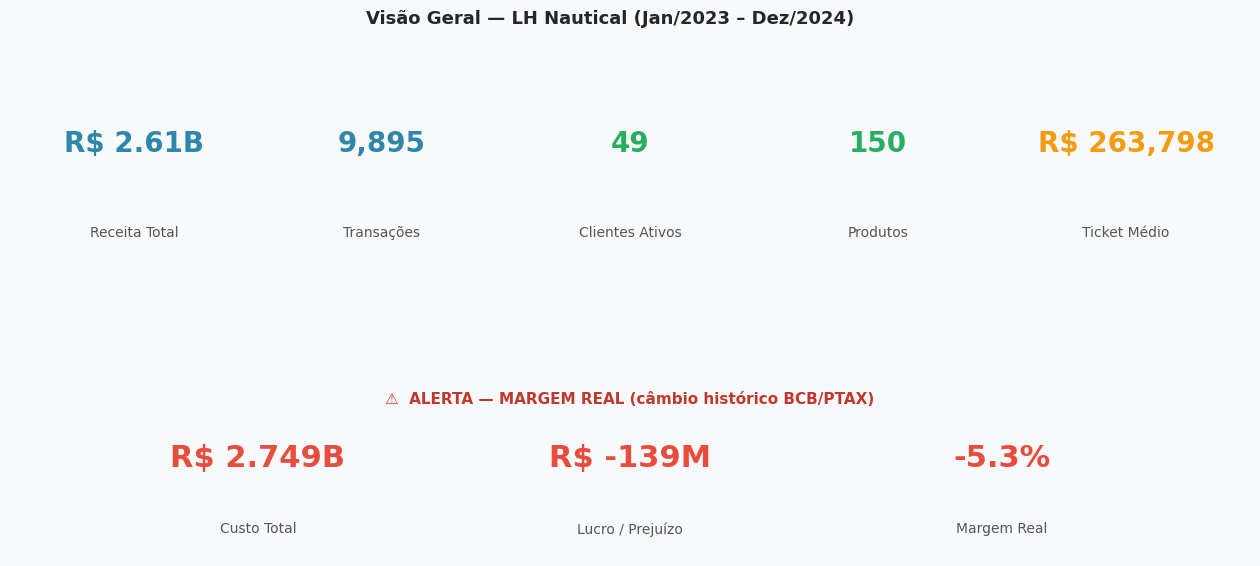

Receita Total   : R$ 2.61B
Transações      : 9,895
Clientes Ativos : 49
Produtos        : 150
Ticket Médio    : R$ 263,798
Custo Total     : R$ 2.749B
Lucro/Prejuízo  : R$ -139M
Margem Real     : -5.3%


In [0]:
# KPIs principais — linha de volume
kpis = spark.sql("""
    SELECT
        COUNT(*)                           AS transacoes,
        COUNT(DISTINCT id_client)          AS clientes,
        COUNT(DISTINCT id_product)         AS produtos,
        ROUND(SUM(total) / 1e9, 3)         AS receita_bi,
        ROUND(AVG(total), 0)               AS ticket_medio
    FROM workspace.lh_nautical.gold_fct_vendas
""").toPandas().iloc[0]

# KPIs de margem
margem_kpi = spark.sql("""
    SELECT
        ROUND(SUM(total)/1e9, 3)                AS receita_bi,
        ROUND(SUM(custo_brl)/1e9, 3)            AS custo_bi,
        ROUND(SUM(lucro)/1e6, 0)                AS lucro_m,
        ROUND(SUM(lucro)/SUM(total)*100,1)      AS margem_pct
    FROM workspace.lh_nautical.gold_fct_vendas
""").toPandas().iloc[0]

# Evolução mensal
mensal_margem = spark.sql("""
    SELECT
        ano_mes,
        ROUND(SUM(total)/1e6, 2)                AS receita_m,
        ROUND(SUM(lucro)/1e6, 2)                AS lucro_m,
        ROUND(SUM(lucro)/SUM(total)*100,1)      AS margem_pct,
        ROUND(AVG(taxa_brl), 3)                 AS taxa_media
    FROM workspace.lh_nautical.gold_fct_vendas
    GROUP BY ano_mes ORDER BY ano_mes
""").toPandas()

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(2, 1, hspace=0.6)

# Linha 1: volume
ax_vol = fig.add_subplot(gs[0])
ax_vol.set_facecolor('white')
ax_vol.axis('off')
metricas_vol = [
    ('Receita Total',   f'R$ {kpis["receita_bi"]}B',        COR_PRIMARIA),
    ('Transações',      f'{int(kpis["transacoes"]):,}',      COR_PRIMARIA),
    ('Clientes Ativos', f'{int(kpis["clientes"])}',          COR_POSITIVO),
    ('Produtos',        f'{int(kpis["produtos"])}',          COR_POSITIVO),
    ('Ticket Médio',    f'R$ {int(kpis["ticket_medio"]):,}', COR_RISCO),
]
for i, (label, valor, cor) in enumerate(metricas_vol):
    x_pos = 0.1 + i * 0.2
    ax_vol.text(x_pos, 0.72, valor, ha='center', va='center',
                fontsize=20, fontweight='bold', color=cor, transform=ax_vol.transAxes)
    ax_vol.text(x_pos, 0.22, label, ha='center', va='center',
                fontsize=10, color='#555', transform=ax_vol.transAxes)

# Linha 2: margem (destaque em vermelho — alerta)
ax_mar = fig.add_subplot(gs[1])
ax_mar.set_facecolor('#fdedec')
ax_mar.axis('off')
ax_mar.text(0.5, 0.88, '⚠  ALERTA — MARGEM REAL (câmbio histórico BCB/PTAX)',
            ha='center', va='center', fontsize=11, fontweight='bold',
            color='#c0392b', transform=ax_mar.transAxes)
metricas_mar = [
    ('Custo Total',      f'R$ {margem_kpi["custo_bi"]}B',     COR_DESTAQUE),
    ('Lucro / Prejuízo', f'R$ {int(margem_kpi["lucro_m"]):,}M', COR_DESTAQUE),
    ('Margem Real',      f'{margem_kpi["margem_pct"]}%',       COR_DESTAQUE),
]
for i, (label, valor, cor) in enumerate(metricas_mar):
    x_pos = 0.2 + i * 0.3
    ax_mar.text(x_pos, 0.55, valor, ha='center', va='center',
                fontsize=22, fontweight='bold', color=cor, transform=ax_mar.transAxes)
    ax_mar.text(x_pos, 0.15, label, ha='center', va='center',
                fontsize=10, color='#555', transform=ax_mar.transAxes)

fig.suptitle('Visão Geral — LH Nautical (Jan/2023 – Dez/2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# --- resumo textual ---
print(f'Receita Total   : R$ {kpis["receita_bi"]}B')
print(f'Transações      : {int(kpis["transacoes"]):,}')
print(f'Clientes Ativos : {int(kpis["clientes"])}')
print(f'Produtos        : {int(kpis["produtos"])}')
print(f'Ticket Médio    : R$ {int(kpis["ticket_medio"]):,}')
print(f'Custo Total     : R$ {margem_kpi["custo_bi"]}B')
print(f'Lucro/Prejuízo  : R$ {int(margem_kpi["lucro_m"]):,}M')
print(f'Margem Real     : {margem_kpi["margem_pct"]}%')

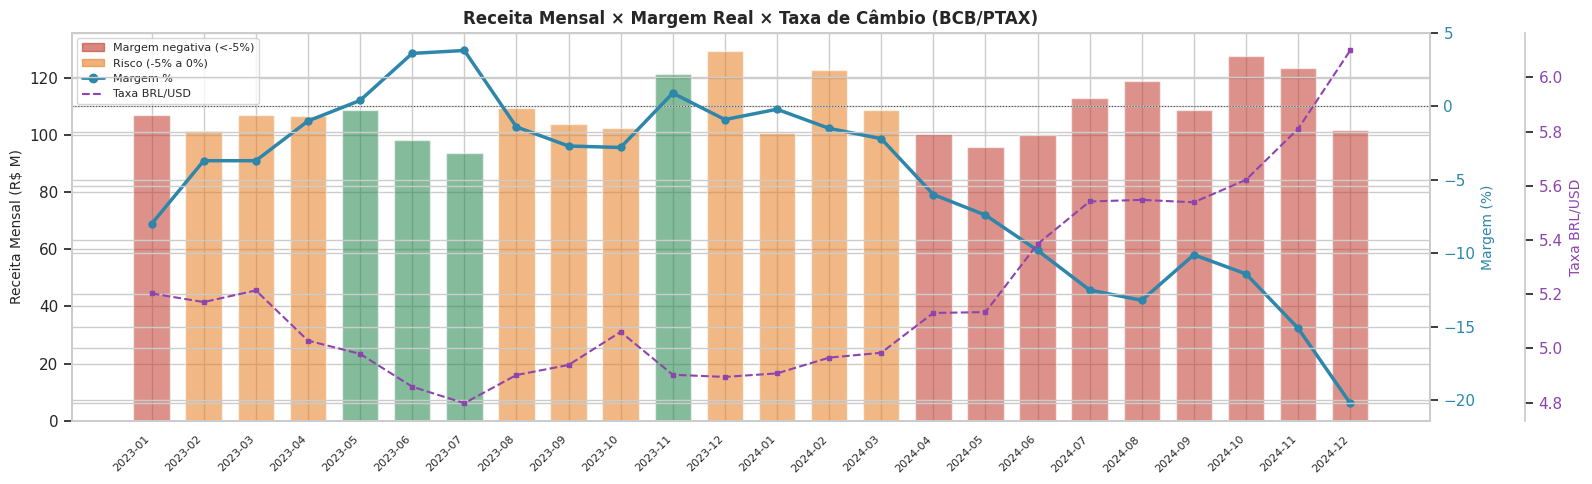

Meses com margem negativa (<-5%): 10/24
Meses em risco (-5% a 0%)       : 10/24
Taxa média no período            : R$ 5.193
Taxa final (Dez/2024)            : R$ 6.099


In [0]:
# Evolução mensal: receita × margem × taxa de câmbio
# REFATORADO: Agora consumimos os cálculos já prontos da Camada Ouro!

mensal_margem = spark.sql("""
    SELECT
        DATE_FORMAT(sale_date, 'yyyy-MM') AS ano_mes,
        ROUND(SUM(total)/1e6, 2)                   AS receita_m,
        ROUND(SUM(lucro)/1e6, 2)                   AS lucro_m,
        ROUND(SUM(lucro)/SUM(total)*100, 1)        AS margem_pct,
        ROUND(AVG(taxa_brl), 3)                    AS taxa_media
    FROM workspace.lh_nautical.gold_fct_vendas
    GROUP BY 1 
    ORDER BY 1
""").toPandas()

# ==========================================
# O CÓDIGO DO GRÁFICO CONTINUA EXATAMENTE IGUAL
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.07))
ax3.spines['right'].set_visible(True)

x = range(len(mensal_margem))
cores_bar = ['#c0392b' if m < -5 else '#e67e22' if m < 0 else '#1e8449'
             for m in mensal_margem['margem_pct']]
ax1.bar(x, mensal_margem['receita_m'], color=cores_bar, alpha=0.55, width=0.7)
ax2.plot(x, mensal_margem['margem_pct'], color=COR_PRIMARIA, linewidth=2.5,
         marker='o', markersize=5, zorder=5)
ax3.plot(x, mensal_margem['taxa_media'], color='#8e44ad', linewidth=1.5,
         linestyle='--', marker='s', markersize=3, zorder=4)

ax2.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
ax1.set_xticks(list(x))
ax1.set_xticklabels(mensal_margem['ano_mes'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Receita Mensal (R$ M)', fontsize=10)
ax2.set_ylabel('Margem (%)', fontsize=10, color=COR_PRIMARIA)
ax3.set_ylabel('Taxa BRL/USD', fontsize=10, color='#8e44ad')
ax2.tick_params(axis='y', labelcolor=COR_PRIMARIA)
ax3.tick_params(axis='y', labelcolor='#8e44ad')

legend_elements = [
    mpatches.Patch(color='#c0392b', alpha=0.6, label='Margem negativa (<-5%)'),
    mpatches.Patch(color='#e67e22', alpha=0.6, label='Risco (-5% a 0%)'),
    plt.Line2D([0], [0], color=COR_PRIMARIA, linewidth=2, marker='o', label='Margem %'),
    plt.Line2D([0], [0], color='#8e44ad', linewidth=1.5, linestyle='--', label='Taxa BRL/USD'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=8)
ax1.set_title('Receita Mensal × Margem Real × Taxa de Câmbio (BCB/PTAX)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Meses com margem negativa (<-5%): {(mensal_margem["margem_pct"] < -5).sum()}/24')
print(f'Meses em risco (-5% a 0%)       : {((mensal_margem["margem_pct"] >= -5) & (mensal_margem["margem_pct"] < 0)).sum()}/24')
print(f'Taxa média no período            : R$ {mensal_margem["taxa_media"].mean():.3f}')
print(f'Taxa final (Dez/2024)            : R$ {mensal_margem["taxa_media"].iloc[-1]:.3f}')

---
## 4. A Crise de Margem — O Achado Central

O crescimento de receita de +2,5% (2023→2024) esconde um problema estrutural: **a operação está vendendo abaixo do custo de importação**.

Quando os custos em USD são convertidos pela taxa PTAX/BCB do dia de cada venda, o resultado revela uma **margem real de -5,3%** — equivalente a R$-139M de prejuízo acumulado em 2 anos.

**Causa raiz:** A taxa de câmbio histórica (R$4,72 a R$6,20 no período) erode a margem de produtos importados. O break-even de todos os 150 produtos está abaixo da taxa atual de R$6,19 — nenhum produto é lucrativo ao câmbio corrente.

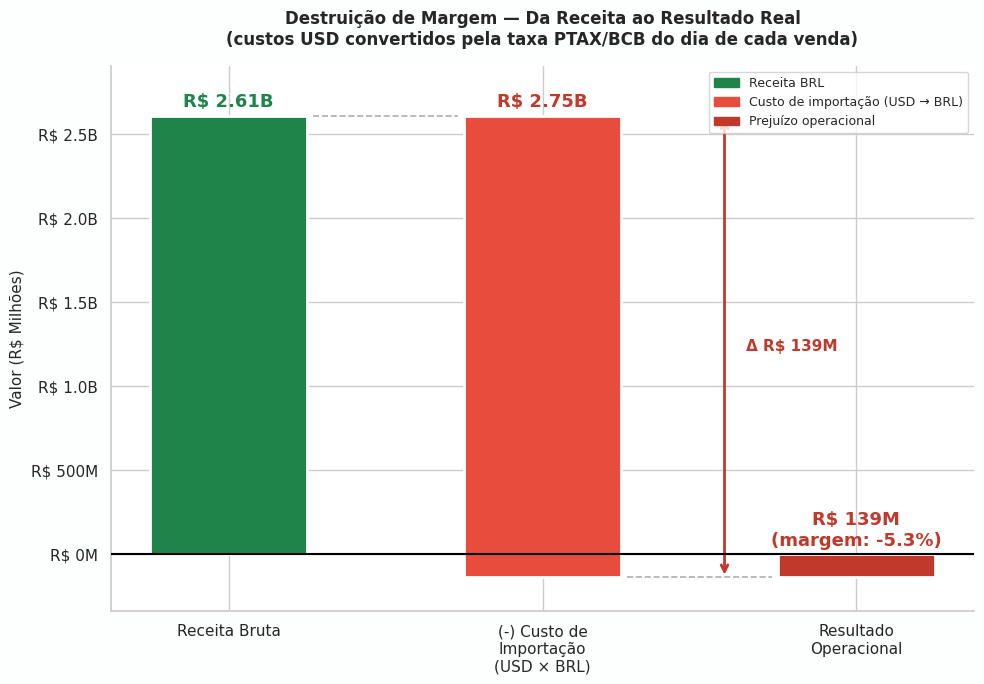

Receita total : R$ 2,610M  (R$ 2.610B)
Custo total   : R$ 2,749M  (R$ 2.749B)
Resultado     : R$ -139M
Margem real   : -5.3%
——————————————————————————————————————————————————
O câmbio USD→BRL corroeu toda a margem bruta e gerou R$-139M de prejuízo acumulado.


In [0]:
# Waterfall Chart — Destruição de Margem
resultado_wf = spark.sql("""
    SELECT
        ROUND(SUM(total) / 1e6, 0)      AS receita_m,
        ROUND(SUM(custo_brl) / 1e6, 0)  AS custo_m
    FROM workspace.lh_nautical.gold_fct_vendas
""").toPandas().iloc[0]

receita_m = int(resultado_wf['receita_m'])
custo_m   = int(resultado_wf['custo_m'])
result_m  = receita_m - custo_m  # negativo

# --- Waterfall ---
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#fdfefe')

categories  = ['Receita Bruta', '(-) Custo de\nImportação\n(USD × BRL)', 'Resultado\nOperacional']
bar_bottoms = [0,        result_m,      result_m     ]
bar_heights = [receita_m, custo_m,      abs(result_m)]
bar_colors  = ['#1e8449', '#e74c3c',    '#c0392b'    ]

bars = ax.bar(categories, bar_heights, bottom=bar_bottoms,
              color=bar_colors, width=0.5, edgecolor='white', linewidth=2, zorder=3)

# Linha zero
ax.axhline(0, color='black', linewidth=1.5, zorder=4)

# Linhas conectoras (tracejadas)
ax.plot([0.27, 0.73], [receita_m, receita_m], 'k--', lw=1.2, alpha=0.35, zorder=5)
ax.plot([1.27, 1.73], [result_m,  result_m],  'k--', lw=1.2, alpha=0.35, zorder=5)

# Rótulos de valor
ax.text(0, receita_m + 55, f'R$ {receita_m/1000:.2f}B',
        ha='center', fontsize=13, fontweight='bold', color='#1e8449')
ax.text(1, receita_m + 55, f'R$ {custo_m/1000:.2f}B',
        ha='center', fontsize=13, fontweight='bold', color='#c0392b')
ax.text(2, 25,
        f'R$ {abs(result_m):,}M\n(margem: {result_m / receita_m * 100:.1f}%)',
        ha='center', fontsize=13, fontweight='bold', color='#c0392b', va='bottom')

# Seta bidirecional mostrando o delta
ax.annotate('', xy=(1.58, result_m), xytext=(1.58, receita_m),
            arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=2))
ax.text(1.65, (receita_m + result_m) / 2,
        f'Δ R$ {abs(result_m):,}M',
        va='center', fontsize=11, color='#c0392b', fontweight='bold')

ax.set_ylabel('Valor (R$ Milhões)', fontsize=11)
ax.set_title(
    'Destruição de Margem — Da Receita ao Resultado Real\n'
    '(custos USD convertidos pela taxa PTAX/BCB do dia de cada venda)',
    fontsize=12, fontweight='bold', pad=15
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.1f}B' if abs(x) >= 1000 else f'R$ {int(x)}M')
)
ax.set_ylim(result_m - 200, receita_m + 300)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_el = [
    mpatches.Patch(color='#1e8449', label='Receita BRL'),
    mpatches.Patch(color='#e74c3c', label='Custo de importação (USD → BRL)'),
    mpatches.Patch(color='#c0392b', label='Prejuízo operacional'),
]
ax.legend(handles=legend_el, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Receita total : R$ {receita_m:,}M  (R$ {receita_m/1000:.3f}B)')
print(f'Custo total   : R$ {custo_m:,}M  (R$ {custo_m/1000:.3f}B)')
print(f'Resultado     : R$ {result_m:,}M')
print(f'Margem real   : {result_m / receita_m * 100:.1f}%')
print('—' * 50)
print('O câmbio USD→BRL corroeu toda a margem bruta e gerou R$-139M de prejuízo acumulado.')

---
## 5. Lucratividade por Produto *(Questão 4)*

Com o câmbio histórico PTAX/BCB, é possível calcular a **margem real por produto** — a relação entre receita gerada e custo de importação convertido pela taxa do dia de cada venda. Este é o dado que fundamenta qualquer decisão de precificação.

Os gráficos mostram os 15 produtos com menor margem (candidatos urgentes a reajuste) e os 10 com maior margem histórica (menos negativos — candidatos prioritários para recuperar lucratividade com ajuste menor).

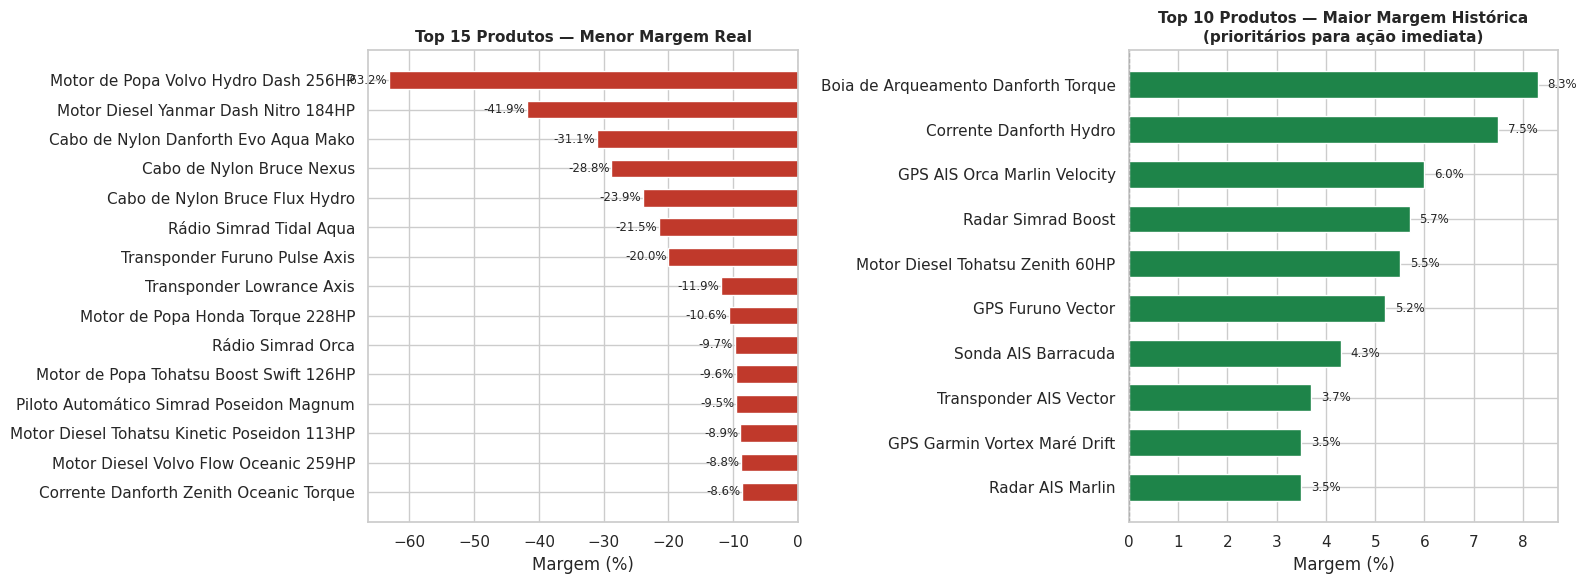

Produtos com margem positiva   : 23/150
Produtos em risco (-5% a 0%)   : 75/150
Produtos margem negativa (<-5%): 51/150
Margem média geral             : -4.4%


In [0]:
# Margem real por produto
margem_prod = spark.sql("""
    SELECT
        v.id_product,
        p.name            AS produto,
        p.actual_category AS categoria,
        ROUND(SUM(v.total)/1e6, 2)               AS receita_m,
        ROUND(SUM(v.custo_brl)/1e6, 2)           AS custo_m,
        ROUND(SUM(v.lucro)/SUM(v.total)*100, 1)  AS margem_pct,
        ROUND(SUM(v.lucro), 2)                   AS lucro_total
    FROM workspace.lh_nautical.gold_fct_vendas v
    JOIN workspace.lh_nautical.silver_produtos p ON v.id_product = p.id_product
    GROUP BY v.id_product, p.name, p.actual_category
    ORDER BY margem_pct ASC
""").toPandas()

piores   = margem_prod.head(15)
melhores = margem_prod.nlargest(10, 'margem_pct')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Piores margens
cores_p = ['#c0392b' if m < -5 else '#e67e22' for m in piores['margem_pct']]
bars = ax1.barh(piores['produto'], piores['margem_pct'], color=cores_p, height=0.6)
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Top 15 Produtos — Menor Margem Real', fontsize=11, fontweight='bold')
ax1.set_xlabel('Margem (%)')
ax1.invert_yaxis()
for bar, row in zip(bars, piores.itertuples()):
    ax1.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
             f'{row.margem_pct}%', va='center', ha='right', fontsize=8.5)

# Melhores margens (candidatos à precificação prioritária)
cores_m = ['#1e8449' if m >= 0 else '#e67e22' if m >= -5 else '#c0392b'
           for m in melhores['margem_pct']]
bars2 = ax2.barh(melhores['produto'], melhores['margem_pct'], color=cores_m, height=0.6)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Top 10 Produtos — Maior Margem Histórica\n(prioritários para ação imediata)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Margem (%)')
ax2.invert_yaxis()
for bar, row in zip(bars2, melhores.itertuples()):
    offset = 0.2 if row.margem_pct >= 0 else -0.2
    ha     = 'left' if row.margem_pct >= 0 else 'right'
    ax2.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
             f'{row.margem_pct}%', va='center', ha=ha, fontsize=8.5)

plt.tight_layout()
plt.show()

positivos = (margem_prod['lucro_total'] > 0).sum()
risco     = ((margem_prod['margem_pct'] < 0) & (margem_prod['margem_pct'] >= -5)).sum()
negativos = (margem_prod['margem_pct'] < -5).sum()
print(f'Produtos com margem positiva   : {positivos}/150')
print(f'Produtos em risco (-5% a 0%)   : {risco}/150')
print(f'Produtos margem negativa (<-5%): {negativos}/150')
print(f'Margem média geral             : {margem_prod["margem_pct"].mean():.1f}%')

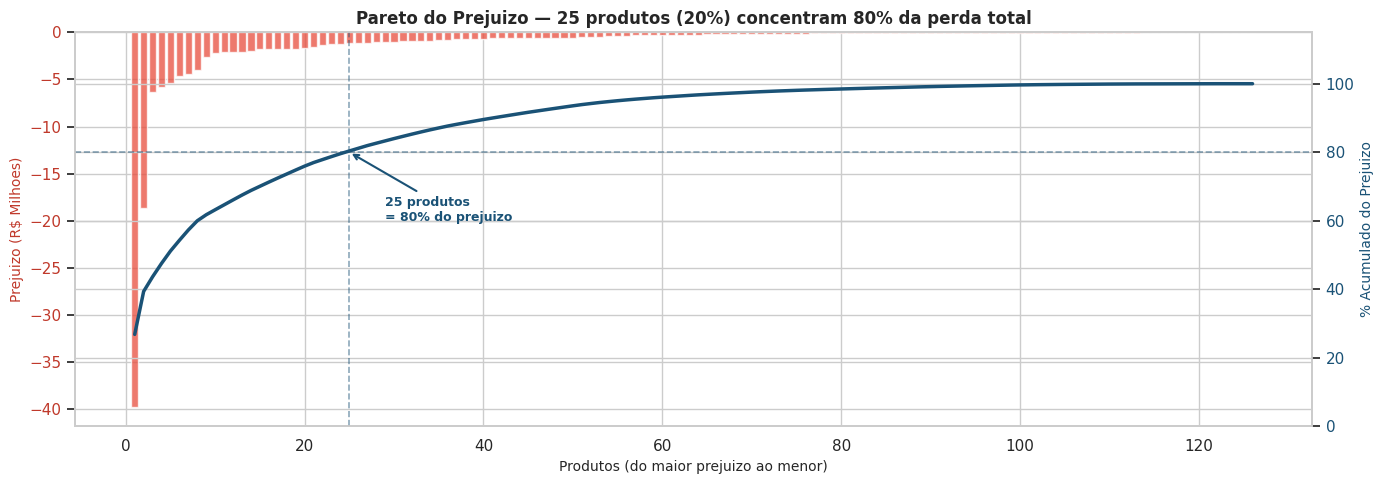

Produtos negativos        : 126/150
Prejuizo bruto (negativos): R$ 148M
Ganho (24 prod. positivos): R$ +10M
Resultado liquido         : R$ -139M  <- o R$-139M do relatorio
Produtos para 80% da perda: 25 (20% dos negativos)

Insight: corrigir 25 produtos elimina 80% do prejuizo bruto.


In [0]:
# Pareto do Prejuizo — quais produtos concentram 80% da perda?
produtos_neg = margem_prod[margem_prod['margem_pct'] < 0].copy()
produtos_neg = (
    produtos_neg
    .assign(lucro_m=lambda d: d['receita_m'] - d['custo_m'])
    .sort_values('lucro_m')
    .reset_index(drop=True)
)
produtos_neg['rank'] = range(1, len(produtos_neg) + 1)
prejuizo_total = produtos_neg['lucro_m'].sum()
produtos_neg['acum_pct'] = produtos_neg['lucro_m'].cumsum() / prejuizo_total * 100

idx_80 = int((produtos_neg['acum_pct'] >= 80).idxmax())
n_80   = idx_80 + 1

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(produtos_neg['rank'], produtos_neg['lucro_m'],
        color='#e74c3c', alpha=0.75, width=0.8)
ax1.set_xlabel('Produtos (do maior prejuizo ao menor)', fontsize=10)
ax1.set_ylabel('Prejuizo (R$ Milhoes)', color='#c0392b', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_title(
    f'Pareto do Prejuizo — {n_80} produtos ({n_80/len(produtos_neg)*100:.0f}%)'
    f' concentram 80% da perda total',
    fontsize=12, fontweight='bold'
)

ax2 = ax1.twinx()
ax2.plot(produtos_neg['rank'], produtos_neg['acum_pct'],
         color='#1a5276', linewidth=2.5, zorder=5)
ax2.axhline(80, color='#1a5276', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.axvline(n_80, color='#1a5276', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.annotate(
    str(n_80) + ' produtos' + chr(10) + '= 80% do prejuizo',
    xy=(n_80, 80), xytext=(n_80 + 4, 60),
    fontsize=9, fontweight='bold', color='#1a5276',
    arrowprops=dict(arrowstyle='->', color='#1a5276', lw=1.5)
)
ax2.set_ylabel('% Acumulado do Prejuizo', color='#1a5276', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#1a5276')
ax2.set_ylim(0, 115)

plt.tight_layout()
plt.show()

n_positivos = (margem_prod['lucro_total'] > 0).sum()
ganho_pos = (
    margem_prod[margem_prod['lucro_total'] > 0]
    .assign(lucro_m=lambda d: d['receita_m'] - d['custo_m'])['lucro_m']
    .sum()
)
print(f'Produtos negativos        : {len(produtos_neg)}/150')
print(f'Prejuizo bruto (negativos): R$ {abs(prejuizo_total):.0f}M')
print(f'Ganho ({n_positivos} prod. positivos): R$ +{ganho_pos:.0f}M')
print(f'Resultado liquido         : R$ {(prejuizo_total + ganho_pos):.0f}M  <- o R$-139M do relatorio')
print(f'Produtos para 80% da perda: {n_80} ({n_80/len(produtos_neg)*100:.0f}% dos negativos)')
print()
print(f'Insight: corrigir {n_80} produtos elimina 80% do prejuizo bruto.')

---
## 6. Clientes com Maior Receita e Margem Real *(Questão 5)*

Os mesmos 15 clientes analisados em duas dimensões simultâneas: **receita acumulada** (quanto geraram) e **margem real** (câmbio PTAX/BCB). A comparação revela que o ranking de receita não reflete o ranking de rentabilidade.

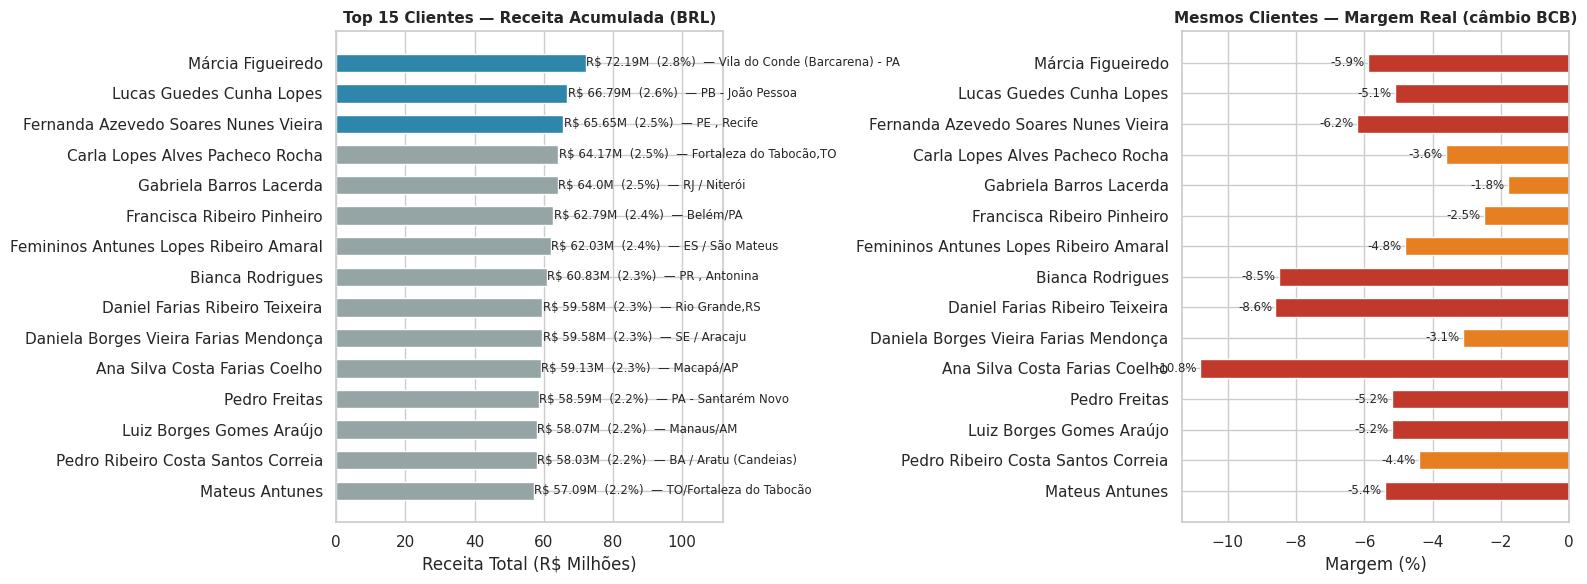

Top 10 clientes = 24.6% da receita total
Margem média dos top 15: -5.4%
Nota: todos os clientes com margem negativa — reflexo da crise cambial sistêmica


In [0]:
# Top 15 clientes
receita_cli = spark.sql("""
    SELECT
        c.full_name AS cliente,
        c.location,
        COUNT(v.id)                                                AS compras,
        ROUND(SUM(v.total)/1e6, 2)                                 AS receita_m,
        ROUND(100.0 * SUM(v.total) / SUM(SUM(v.total)) OVER(), 1)  AS pct,
        ROUND(SUM(v.lucro)/SUM(v.total)*100, 1)                    AS margem_pct
    FROM workspace.lh_nautical.silver_clientes c
    JOIN workspace.lh_nautical.gold_fct_vendas v ON c.id_client = v.id_client
    GROUP BY c.full_name, c.location
    ORDER BY receita_m DESC
    LIMIT 15
""").toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Receita
cores = [COR_PRIMARIA if i < 3 else COR_NEUTRO for i in range(len(receita_cli))]
bars = ax1.barh(receita_cli['cliente'], receita_cli['receita_m'], color=cores, height=0.6)
ax1.set_title('Top 15 Clientes — Receita Acumulada (BRL)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Receita Total (R$ Milhões)')
ax1.invert_yaxis()
for bar, row in zip(bars, receita_cli.itertuples()):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'R$ {row.receita_m}M  ({row.pct}%)  — {row.location}',
             va='center', fontsize=8.5)
ax1.set_xlim(0, receita_cli['receita_m'].max() * 1.55)

# Margem real dos mesmos clientes
cores_m = ['#c0392b' if m < -5 else '#e67e22' if m < 0 else '#1e8449'
           for m in receita_cli['margem_pct']]
bars2 = ax2.barh(receita_cli['cliente'], receita_cli['margem_pct'], color=cores_m, height=0.6)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Mesmos Clientes — Margem Real (câmbio BCB)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Margem (%)')
ax2.invert_yaxis()
for bar, row in zip(bars2, receita_cli.itertuples()):
    offset = 0.1 if row.margem_pct >= 0 else -0.1
    ha     = 'left' if row.margem_pct >= 0 else 'right'
    ax2.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
             f'{row.margem_pct}%', va='center', ha=ha, fontsize=8.5)

plt.tight_layout()
plt.show()

top10_pct = receita_cli.head(10)['pct'].sum()
print(f'Top 10 clientes = {top10_pct:.1f}% da receita total')
print(f'Margem média dos top 15: {receita_cli["margem_pct"].mean():.1f}%')
print('Nota: todos os clientes com margem negativa — reflexo da crise cambial sistêmica')

---
## 7. Vendas Médias por Dia da Semana *(Questão 6)*

Metodologia: calendário completo de 731 dias com `sequence()` → `LEFT JOIN` com vendas → dias sem venda entram como R$ 0 → média calculada sobre todos os dias.

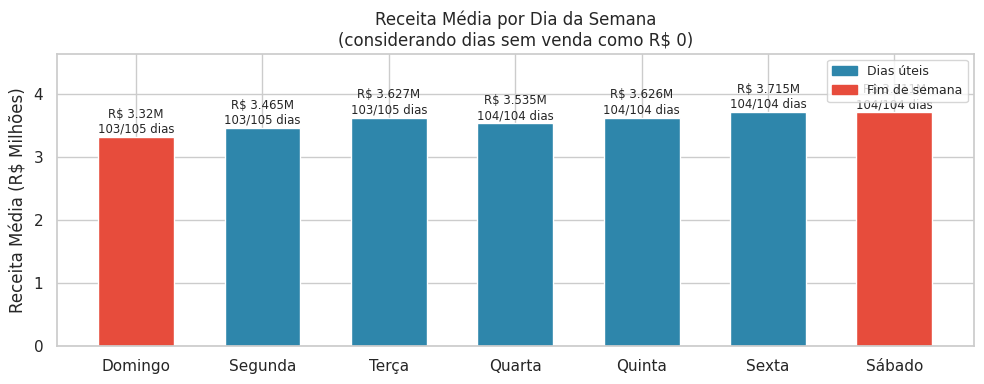

dia_semana  media_m  dias_com_venda  total_dias
   Domingo    3.320             103         105
   Segunda    3.465             103         105
     Terça    3.627             103         105
    Quarta    3.535             104         104
    Quinta    3.626             104         104
     Sexta    3.715             104         104
    Sábado    3.711             104         104


In [0]:
dia_semana = spark.sql("""
    WITH calendario AS (
        SELECT explode(sequence(to_date('2023-01-01'), to_date('2024-12-31'), interval 1 day)) AS dia
    ),
    vendas_dia AS (
        SELECT sale_date, SUM(total) AS receita
        FROM workspace.lh_nautical.gold_fct_vendas GROUP BY sale_date
    ),
    completo AS (
        SELECT c.dia, COALESCE(v.receita, 0) AS receita
        FROM calendario c LEFT JOIN vendas_dia v ON c.dia = v.sale_date
    )
    SELECT
        (dayofweek(dia) - 1) AS num,
        CASE (dayofweek(dia) - 1)
            WHEN 0 THEN 'Domingo'  WHEN 1 THEN 'Segunda'
            WHEN 2 THEN 'Terça'    WHEN 3 THEN 'Quarta'
            WHEN 4 THEN 'Quinta'   WHEN 5 THEN 'Sexta'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana,
        ROUND(AVG(receita)/1e6, 3) AS media_m,
        SUM(CASE WHEN receita > 0 THEN 1 ELSE 0 END) AS dias_com_venda,
        COUNT(*) AS total_dias
    FROM completo
    GROUP BY num, dia_semana ORDER BY num
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
cores = [COR_DESTAQUE if d in ['Sábado', 'Domingo'] else COR_PRIMARIA
         for d in dia_semana['dia_semana']]
bars = ax.bar(dia_semana['dia_semana'], dia_semana['media_m'],
              color=cores, width=0.6)
ax.set_title('Receita Média por Dia da Semana\n(considerando dias sem venda como R$ 0)')
ax.set_ylabel('Receita Média (R$ Milhões)')
for bar, row in zip(bars, dia_semana.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'R$ {row.media_m}M\n{row.dias_com_venda}/{row.total_dias} dias',
            ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, dia_semana['media_m'].max() * 1.25)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COR_PRIMARIA, label='Dias úteis'),
                   Patch(color=COR_DESTAQUE, label='Fim de semana')], fontsize=9)
plt.tight_layout()
plt.show()
print(dia_semana[["dia_semana","media_m","dias_com_venda","total_dias"]].to_string(index=False))

---
## 8. Previsão de Demanda *(Etapa 5)*

Cinco modelos testados no notebook 08 (Baseline Sazonal, Regressão Linear, Random Forest, Holt Exponential Smoothing, Prophet). O **Baseline Sazonal** apresentou melhor desempenho no conjunto de teste 2024 — MAPE recalculado abaixo no gráfico. Forecast para Jan–Jun/2025 via Naive Sazonal: média histórica × fator mensal — sem recursão de features.

> **Contexto:** com margem atual de -5,3%, cada mês previsto implica prejuízo proporcional.
> Fevereiro é o mês pico do semestre — ver valores projetados no gráfico abaixo.

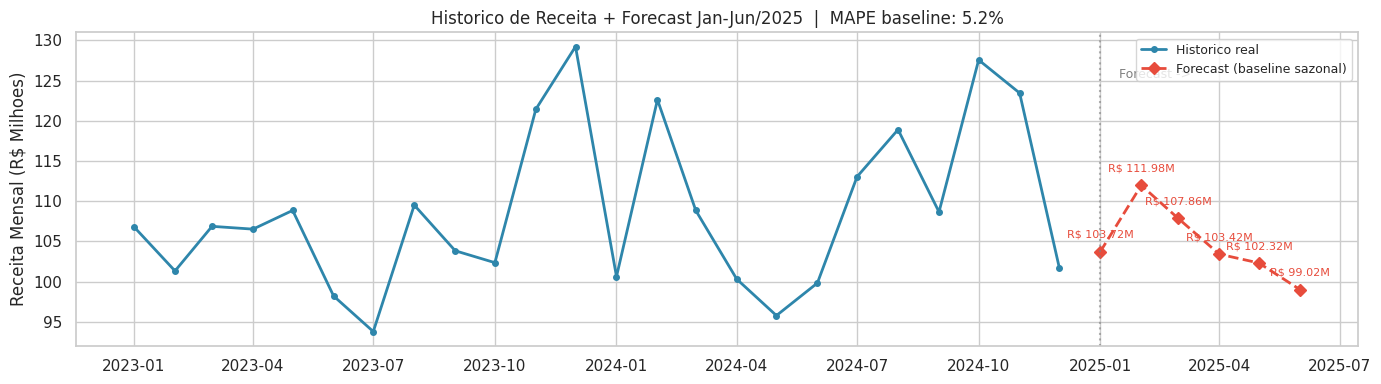

MAPE baseline sazonal (2024): 5.2%
=== FORECAST JAN-JUN/2025 ===
    mes  receita_m
2025-01     103.72
2025-02     111.98
2025-03     107.86
2025-04     103.42
2025-05     102.32
2025-06      99.02
=== HISTÓRICO MENSAL (R$ M) ===
    mes  receita_m
2023-01     106.81
2023-02     101.33
2023-03     106.88
2023-04     106.53
2023-05     108.86
2023-06      98.21
2023-07      93.79
2023-08     109.52
2023-09     103.84
2023-10     102.36
2023-11     121.45
2023-12     129.24
2024-01     100.63
2024-02     122.63
2024-03     108.85
2024-04     100.31
2024-05      95.78
2024-06      99.83
2024-07     113.05
2024-08     118.91
2024-09     108.67
2024-10     127.58
2024-11     123.46
2024-12     101.74


In [0]:
# Historico mensal
historico = spark.sql("""
    SELECT trunc(sale_date, 'MM') AS mes,
           ROUND(SUM(total)/1e6, 2) AS receita_m
    FROM workspace.lh_nautical.gold_fct_vendas
    GROUP BY 1 ORDER BY 1
""").toPandas()
historico['mes'] = pd.to_datetime(historico['mes'])

# MAPE dinamico do baseline sazonal no periodo conhecido de 2024
media_geral  = historico['receita_m'].mean()
fator_mensal = historico.groupby(historico['mes'].dt.month)['receita_m'].mean() / media_geral

hist_2024 = historico[historico['mes'].dt.year == 2024].copy()
hist_2024['pred_baseline'] = hist_2024['mes'].apply(
    lambda d: media_geral * fator_mensal.get(d.month, 1)
 )
mape_baseline = (
    np.mean(np.abs((hist_2024['receita_m'] - hist_2024['pred_baseline']) / hist_2024['receita_m'])) * 100
)

# Forecast com baseline sazonal
meses_2025 = pd.date_range('2025-01-01', periods=6, freq='MS')
forecast   = pd.DataFrame({
    'mes'      : meses_2025,
    'receita_m': [round(media_geral * fator_mensal.get(m.month, 1), 2) for m in meses_2025]
})

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(historico['mes'], historico['receita_m'],
        marker='o', markersize=4, linewidth=2,
        color=COR_PRIMARIA, label='Historico real')
ax.plot(forecast['mes'], forecast['receita_m'],
        marker='D', markersize=6, linewidth=2,
        linestyle='--', color=COR_DESTAQUE, label='Forecast (baseline sazonal)')
ax.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle=':', alpha=0.6)
ax.text(pd.Timestamp('2025-01-15'), historico['receita_m'].max() * 0.97,
        'Forecast ->', fontsize=9, color='gray')
for _, row in forecast.iterrows():
    ax.annotate(f"R$ {row['receita_m']}M",
                (row['mes'], row['receita_m']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color=COR_DESTAQUE)
ax.set_title(f'Historico de Receita + Forecast Jan-Jun/2025  |  MAPE baseline: {mape_baseline:.1f}%')
ax.set_ylabel('Receita Mensal (R$ Milhoes)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'MAPE baseline sazonal (2024): {mape_baseline:.1f}%')
print('=== FORECAST JAN-JUN/2025 ===')
print(forecast.assign(mes=forecast['mes'].dt.strftime('%Y-%m')).to_string(index=False))
print('=== HISTÓRICO MENSAL (R$ M) ===')
print(historico.assign(mes=historico['mes'].dt.strftime('%Y-%m')).to_string(index=False))

---
## 9. Recomendações Estratégicas

### Para a Marina (Gerente de Negócios)

| Prioridade | Ação | Embasamento |
|---|---|---|
| 🔴 Urgente | **Reajustar preços** dos 150 produtos antes de qualquer campanha | Break-even de todos abaixo da taxa atual (R$6,19 em Dez/2024) |
| 🔴 Urgente | Priorizar os **23 produtos com margem histórica positiva** nas vendas imediatas | Único cenário em que vender mais gera resultado positivo |
| 🔴 Alta | Usar `recomendar_content_margem()` em campanhas ativas | Minimiza prejuízo incremental ao priorizar os menos negativos |
| 🔴 Alta | Campanha de retenção para os **10 clientes Em Risco** (RFM) | Antes do churn — eles ainda estão ativos e com pior margem |
| 🟡 Média | Reforçar estoque de motores para **Fevereiro/2025** | Pico histórico confirmado nos 2 anos |
| 🟡 Média | Campanha cross-sell para **Julho** (mês mais fraco) | R$ 93,8M — 14% abaixo da média |
| 🟢 Baixa | Foco em **PA e BA** para expansão | 26,8% da receita concentrados nesses 2 estados |

### Para o Sr. Almir (Fundador)

- **R$ 2,61 bilhões** em 2 anos — operação sólida e recorrente
- **Propulsão é o negócio:** 79,5% da receita vem de motores
- **Nenhum cliente parado:** 49 de 49 compraram no período
- **Alerta crítico:** os custos em dólar, convertidos pelo câmbio real, resultam em **R$-139M de prejuízo acumulado**. A operação cresce em faturamento, mas perde em resultado. **Prioridade número 1: reajuste de preços** alinhado ao câmbio real.
- Com preços corrigidos, o sistema de previsão e recomendação se torna uma ferramenta poderosa para crescer com margem positiva.

---
## 10. Próximos Passos Técnicos

| Prazo | Ação |
|---|---|
| Imediato | **Reajuste de preços** baseado no break-even cambial calculado para cada produto (Etapa 3) |
| Imediato | Ativar `recomendar_content_margem()` em campanhas — prioriza os 22 produtos com margem positiva |
| 30 dias | Conectar banco do e-commerce ao sistema financeiro para unificar dados em tempo real |
| 30 dias | Monitoramento automático da margem com alertas quando taxa BCB superar break-even de cada produto |
| 90 dias | Orquestrar pipelines com Airflow — atualização automática diária das análises |
| 6 meses | Com mais 1 ano de dados, modelos de previsão ganharão precisão significativa |
| 1 ano | Com 3+ anos de histórico, implementar SARIMA ou Prophet com sazonalidade completa |

---
*Relatório gerado com Spark SQL, pandas e scikit-learn. Reproduzível: executar notebooks 04→10 no Databricks workspace.*

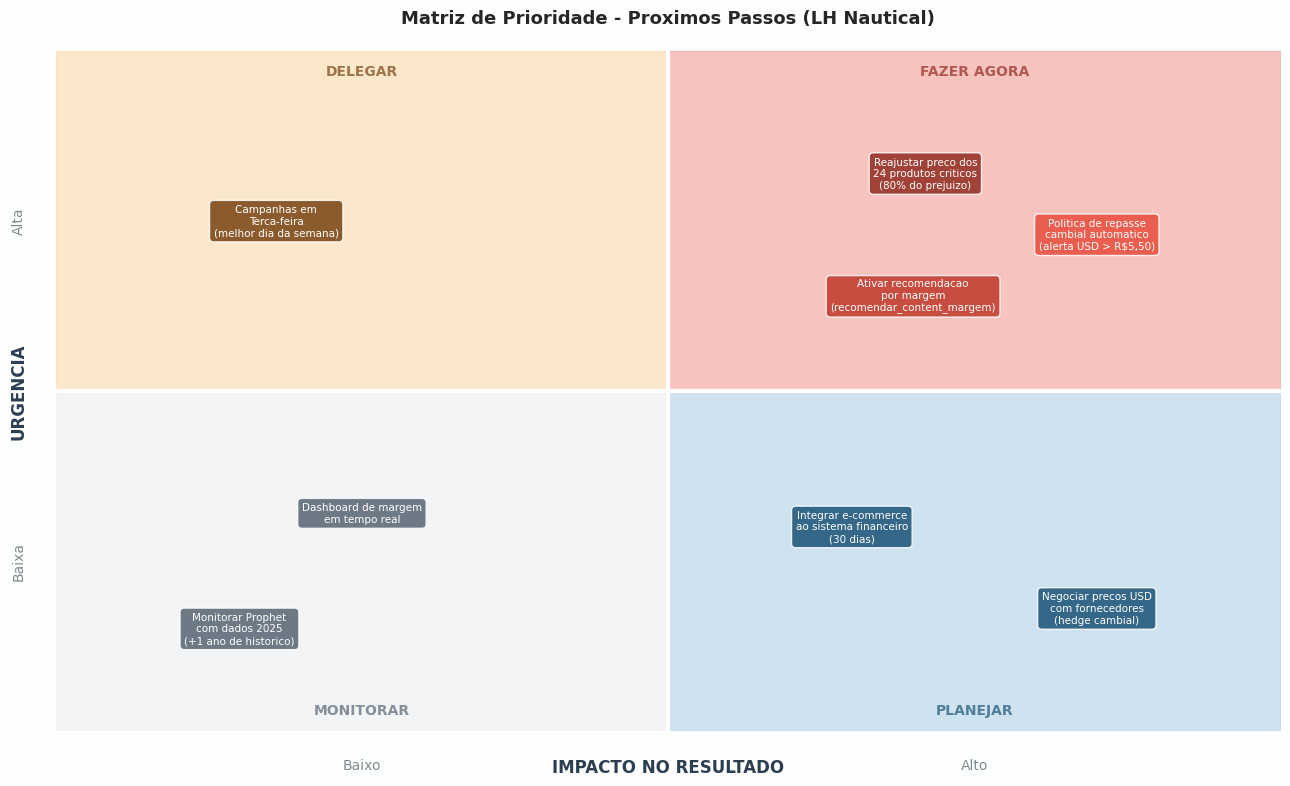

=== MATRIZ DE PRIORIDADE — PRÓXIMOS PASSOS ===
  quadrante                                                       acao
FAZER AGORA Reajustar preco dos 24 produtos criticos (80% do prejuizo)
FAZER AGORA Ativar recomendacao por margem (recomendar_content_margem)
FAZER AGORA Politica de repasse cambial automatico (alerta USD > R,50)
    DELEGAR            Campanhas em Terca-feira (melhor dia da semana)
   PLANEJAR        Integrar e-commerce ao sistema financeiro (30 dias)
   PLANEJAR       Negociar precos USD com fornecedores (hedge cambial)
  MONITORAR                          Dashboard de margem em tempo real
  MONITORAR     Monitorar Prophet com dados 2025 (+1 ano de historico)


In [0]:
# Matriz de Prioridade - Impacto x Urgencia

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#fdfefe')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Quadrantes
quadrantes = [
    (5, 5, 5, 5, '#f1948a', 'FAZER AGORA',   '#922b21', 7.5, 9.6),
    (0, 5, 5, 5, '#fad7a0', 'DELEGAR',       '#784212', 2.5, 9.6),
    (5, 0, 5, 5, '#a9cce3', 'PLANEJAR',      '#1a5276', 7.5, 0.2),
    (0, 0, 5, 5, '#eaecee', 'MONITORAR',     '#566573', 2.5, 0.2),
]
for (x, y, w, h, cor, label, tcor, tx, ty) in quadrantes:
    ax.add_patch(plt.Rectangle((x, y), w, h, color=cor, zorder=1, alpha=0.55))
    ax.text(tx, ty, label, ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=tcor, alpha=0.7, zorder=2)

# Linha divisoria
ax.plot([5, 5], [0, 10], color='white', linewidth=3, zorder=3)
ax.plot([0, 10], [5, 5], color='white', linewidth=3, zorder=3)

# Acoes - (x, y, texto, cor_fundo, cor_texto)
acoes = [
    (7.1, 8.2, 'Reajustar preco dos\n24 produtos criticos\n(80% do prejuizo)', '#922b21', 'white'),
    (7.0, 6.4, 'Ativar recomendacao\npor margem\n(recomendar_content_margem)', '#c0392b', 'white'),
    (8.5, 7.3, 'Politica de repasse\ncambial automatico\n(alerta USD > R$5,50)', '#e74c3c', 'white'),
    (1.8, 7.5, 'Campanhas em\nTerca-feira\n(melhor dia da semana)', '#784212', 'white'),
    (6.5, 3.0, 'Integrar e-commerce\nao sistema financeiro\n(30 dias)', '#1a5276', 'white'),
    (8.5, 1.8, 'Negociar precos USD\ncom fornecedores\n(hedge cambial)', '#1a5276', 'white'),
    (2.5, 3.2, 'Dashboard de margem\nem tempo real', '#566573', 'white'),
    (1.5, 1.5, 'Monitorar Prophet\ncom dados 2025\n(+1 ano de historico)', '#566573', 'white'),
]

for (x, y, texto, bg, fg) in acoes:
    ax.text(x, y, texto, ha='center', va='center', fontsize=7.5, color=fg,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=bg, alpha=0.85, edgecolor='white'),
            zorder=5)

# Eixos
ax.text(5, -0.4, 'IMPACTO NO RESULTADO', ha='center', va='top',
        fontsize=12, fontweight='bold', color='#2c3e50')
ax.text(-0.3, 5, 'URGENCIA', ha='center', va='center', fontsize=12,
        fontweight='bold', color='#2c3e50', rotation=90)
ax.text(2.5, -0.4, 'Baixo', ha='center', va='top', fontsize=10, color='#7f8c8d')
ax.text(7.5, -0.4, 'Alto',  ha='center', va='top', fontsize=10, color='#7f8c8d')
ax.text(-0.3, 2.5, 'Baixa', ha='center', va='center', fontsize=10, color='#7f8c8d', rotation=90)
ax.text(-0.3, 7.5, 'Alta',  ha='center', va='center', fontsize=10, color='#7f8c8d', rotation=90)

ax.set_title('Matriz de Prioridade - Proximos Passos (LH Nautical)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
# --- resumo textual ---
_acoes_txt = [
    ('FAZER AGORA',  'Reajustar preco dos 24 produtos criticos (80% do prejuizo)'),
    ('FAZER AGORA',  'Ativar recomendacao por margem (recomendar_content_margem)'),
    ('FAZER AGORA',  'Politica de repasse cambial automatico (alerta USD > R,50)'),
    ('DELEGAR',      'Campanhas em Terca-feira (melhor dia da semana)'),
    ('PLANEJAR',     'Integrar e-commerce ao sistema financeiro (30 dias)'),
    ('PLANEJAR',     'Negociar precos USD com fornecedores (hedge cambial)'),
    ('MONITORAR',    'Dashboard de margem em tempo real'),
    ('MONITORAR',    'Monitorar Prophet com dados 2025 (+1 ano de historico)'),
]
import pandas as _pd
_mat = _pd.DataFrame(_acoes_txt, columns=['quadrante', 'acao'])
print('=== MATRIZ DE PRIORIDADE — PRÓXIMOS PASSOS ===')
print(_mat.to_string(index=False))


In [0]:
def run_all_quality_checks_apresentacao_final(
    kpis_series,
    margem_series,
    mensal_df,
    margem_prod_df,
    receita_cli_df,
    dia_semana_df,
    forecast_df,
    produtos_neg_df,
    n_80_value,
    total_produtos_esperado: int = 150,
    total_clientes_top_esperado: int = 15,
) -> pd.DataFrame:
    """Checks críticos de consistência da Etapa 7."""
    checks = {
        'kpis_volume_presentes': set(['transacoes', 'clientes', 'produtos', 'receita_bi', 'ticket_medio']).issubset(kpis_series.index),
        'margem_kpi_presente': set(['receita_bi', 'custo_bi', 'lucro_m', 'margem_pct']).issubset(margem_series.index),
        'margem_real_negativa_alerta': float(margem_series.get('margem_pct', 0)) < 0,
        'mensal_24_meses': len(mensal_df) == 24 and mensal_df['ano_mes'].nunique() == 24,
        'margem_produto_150_itens': len(margem_prod_df) == total_produtos_esperado,
        'top_clientes_15_ok': len(receita_cli_df) == total_clientes_top_esperado,
        'dia_semana_7_linhas': len(dia_semana_df) == 7,
        'forecast_6_meses_2025': len(forecast_df) == 6 and forecast_df['mes'].dt.year.eq(2025).all(),
        'pareto_n80_valido': len(produtos_neg_df) > 0 and (1 <= int(n_80_value) <= len(produtos_neg_df)),
    }
    qa = pd.DataFrame({'check': checks.keys(), 'status': checks.values()})
    qa['resultado'] = qa['status'].map({True: 'PASS', False: 'FAIL'})
    return qa

qa_apresentacao_final = run_all_quality_checks_apresentacao_final(
    kpis,
    margem_kpi,
    mensal_margem,
    margem_prod,
    receita_cli,
    dia_semana,
    forecast,
    produtos_neg,
    n_80,
 )
print(qa_apresentacao_final[['check', 'resultado']].to_string(index=False))

if qa_apresentacao_final['status'].all():
    print('RUN_ALL CHECKS (ETAPA 7): PASS')
else:
    print('RUN_ALL CHECKS (ETAPA 7): FAIL')

                      check resultado
      kpis_volume_presentes      PASS
        margem_kpi_presente      PASS
margem_real_negativa_alerta      PASS
            mensal_24_meses      PASS
   margem_produto_150_itens      PASS
         top_clientes_15_ok      PASS
        dia_semana_7_linhas      PASS
      forecast_6_meses_2025      PASS
          pareto_n80_valido      PASS
RUN_ALL CHECKS (ETAPA 7): PASS
